In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time

In [2]:
alpha = 2
beta = 1

def f(x):
    return np.exp(-x**2)


def armar_sistema_sparse(n):
    M = 2**n + 1
    h = 1/(2**n + 1)
    x = np.array([j*h for j in range(M+1)])

    filas = []
    cols = []
    datos = []
    b = np.zeros(M)

    for j in range(1, M):
        fila = j-1
        b[fila] = f(x[j])
        if j-1 == 0:
            b[fila] -= alpha/h**2
        else:
            filas.append(fila); cols.append(j-2); datos.append(1/h**2)
        filas.append(fila); cols.append(j-1); datos.append(-2/h**2)
        if j+1 <= M:
            filas.append(fila); cols.append(j); datos.append(1/h**2)

    # fila de Neumann (backward orden 2)
    filas.append(M-1); cols.append(M-1); datos.append(1.5/h)
    filas.append(M-1); cols.append(M-2); datos.append(-2/h)
    filas.append(M-1); cols.append(M-3); datos.append(0.5/h)
    b[M-1] = beta

    A = sp.csr_matrix((datos, (filas, cols)), shape=(M, M))
    return A, b, x, h

n=10, M=1025, tiempo=0.01s, OK
n=14, M=16385, tiempo=0.08s, OK
n=16, M=65537, tiempo=0.40s, OK
n=18, M=262145, tiempo=1.29s, OK
n=20, M=1048577, tiempo=4.97s, OK
n=22, M=4194305, tiempo=20.90s, OK
listo, n usado: 20


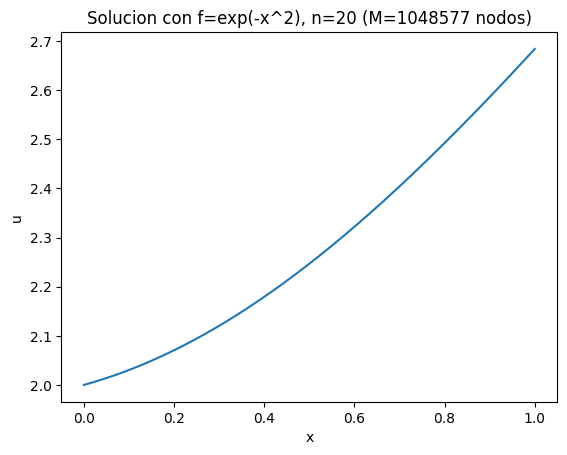

In [3]:
# prueba con n's cada vez mas grandes hasta que se cuelgue o tarde mucho
for n in [10, 14, 16, 18, 20, 22]:
    t0 = time.time()
    try:
        A, b, x, h = armar_sistema_sparse(n)
        U = spla.spsolve(A, b)
        t1 = time.time()
        print(f"n={n}, M={2**n+1}, tiempo={t1-t0:.2f}s, OK")
    except Exception as e:
        print(f"n={n} fallo: {e}")
        break

# me quedo con el n mas grande que funciono bien en tiempo razonable
n_max = 20
A, b, x, h = armar_sistema_sparse(n_max)
U = spla.spsolve(A, b)
U_completo = np.concatenate(([alpha], U))

plt.figure()
plt.plot(x, U_completo)
plt.xlabel("x")
plt.ylabel("u")
plt.title(f"Solucion con f=exp(-x^2), n={n_max} (M={2**n_max+1} nodos)")

print("listo, n usado:", n_max)
